In [4]:
%autoreload 2

UsageError: Line magic function `%autoreload` not found.


In [ ]:
import model as md
import model_2 as m
import numpy as np
import matplotlib.pyplot as plt
import importlib
importlib.reload(md)
N = 1000


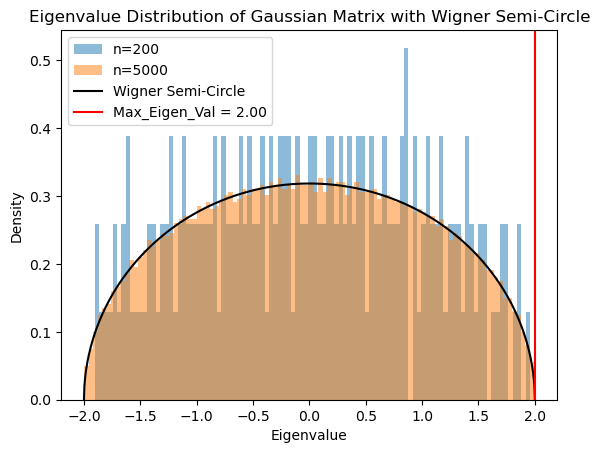

In [ ]:
for N in [200, 5000]:

    M = md.symmetric_gaussian_matrix(N)
    md.plot_eigenvalue_distribution(M, N)
md.show('Eigenvalue', 'Density', 'Eigenvalue Distribution of Gaussian Matrix with Wigner Semi-Circle', 'No_Spike', False, True, True )


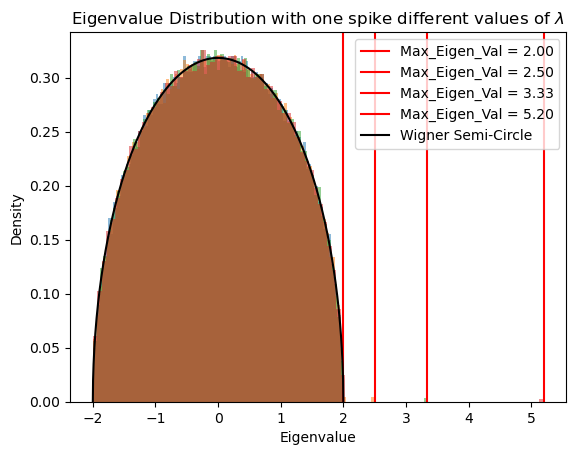

In [19]:
#Location of the Spikes:
lambas = [1, 2, 3, 5]
N = 5000
for lamba in lambas:
    spiked_gaussian = md.spiked_gaussian_matrix(N, lamba)
    md.plot_eigenvalue_distribution(spiked_gaussian, N, True)
    md.plot_Max_Eigenval(lamba)
md.show('Eigenvalue', 'Density', r'Eigenvalue Distribution with one spike different values of $\lambda$', 'many_spikes', False, True, False)


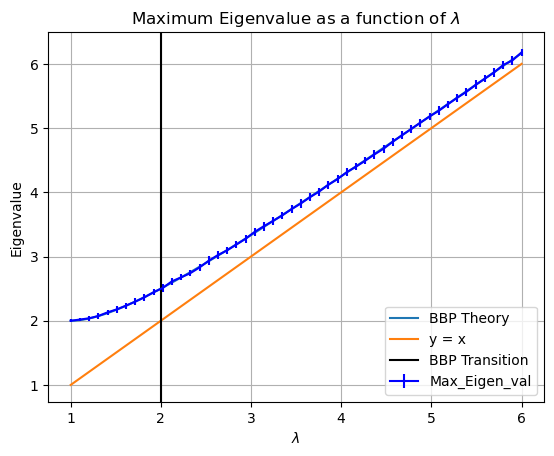

In [20]:
importlib.reload(md)
md.first_look_at_BBP_transi(500)

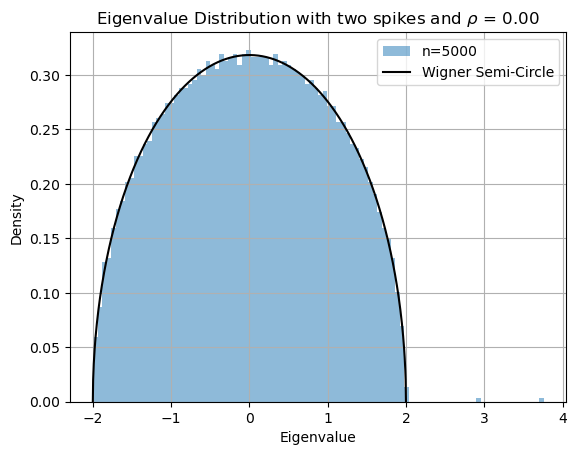

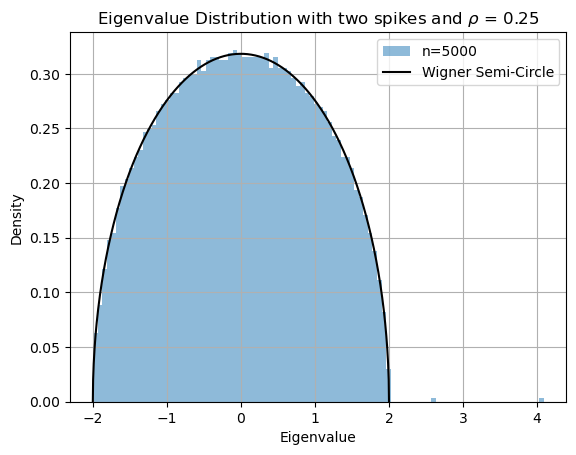

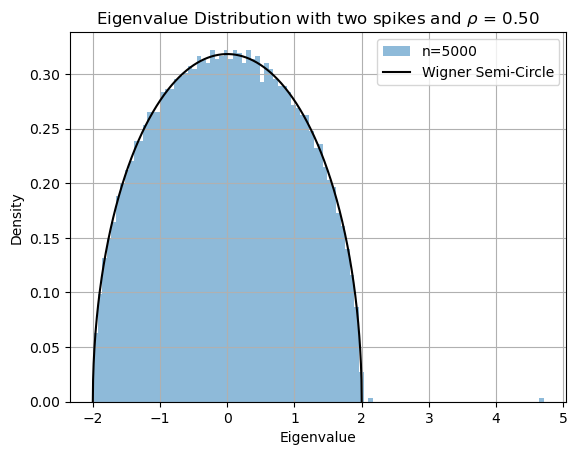

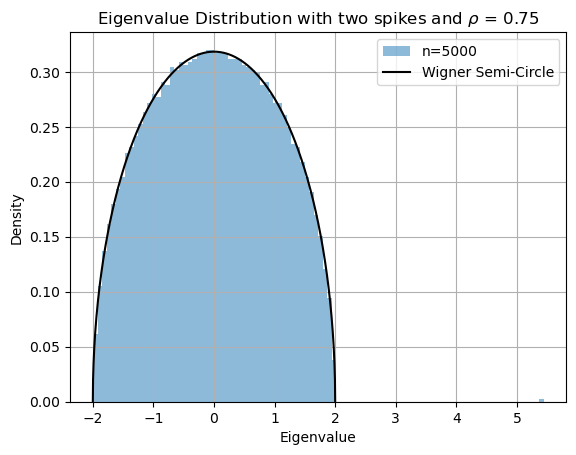

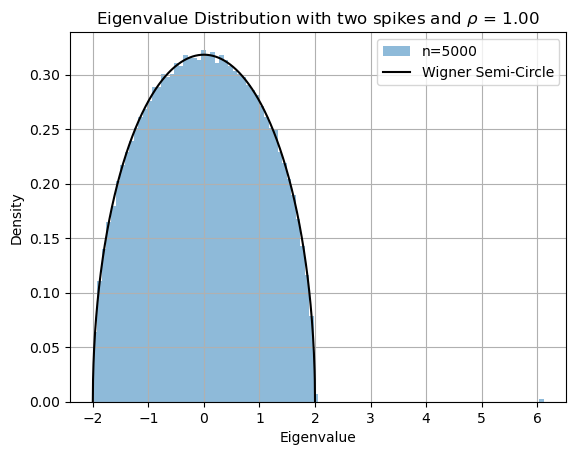

In [30]:
importlib.reload(m)
rhos = np.linspace(0, 1, 5)
lamba_1 = 5
lamba_2 = 4
alpha = 0.5
N = 5000

for rho in rhos:
    M = m.TwoSpikedWignerMatrix(N, lamba_1, lamba_2, rho, alpha)
    M.plot_eigenvalue_distribution()
    M.ploplote(title = rf'Eigenvalue Distribution with two spikes and $\rho$ = {rho:.2f}', savefig = f'Two_Spiked_Wigner_rho_{rho:.2f}', Wigner=True, grid=True)

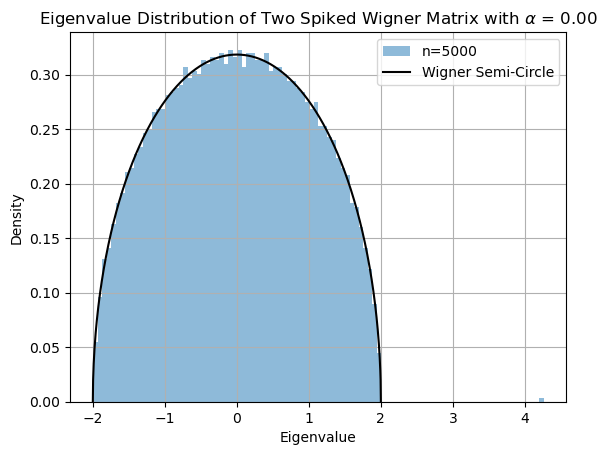

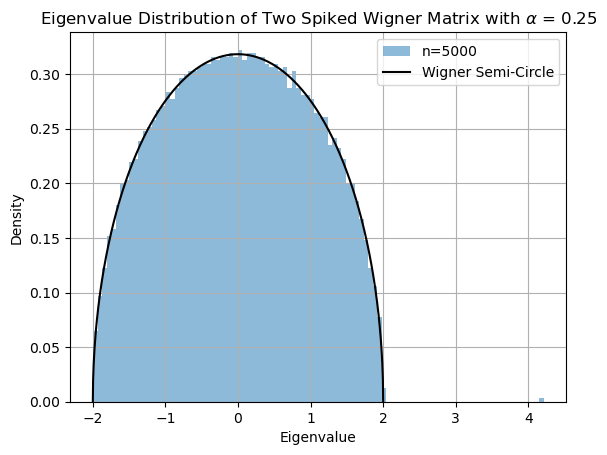

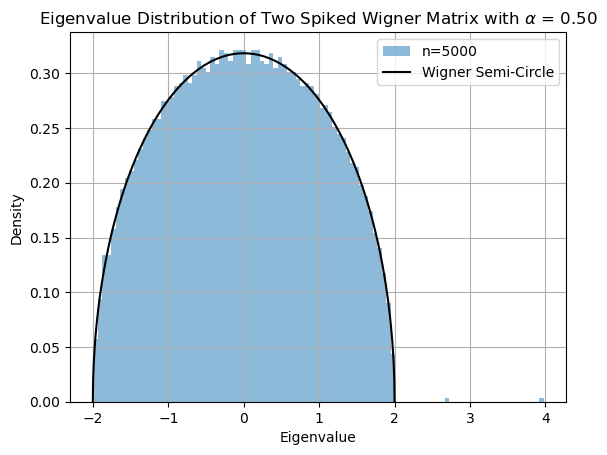

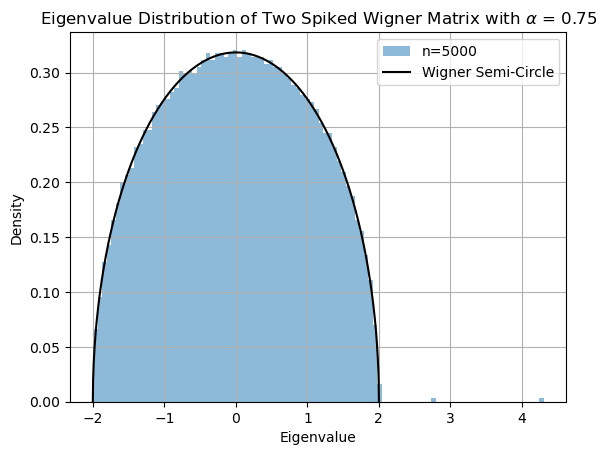

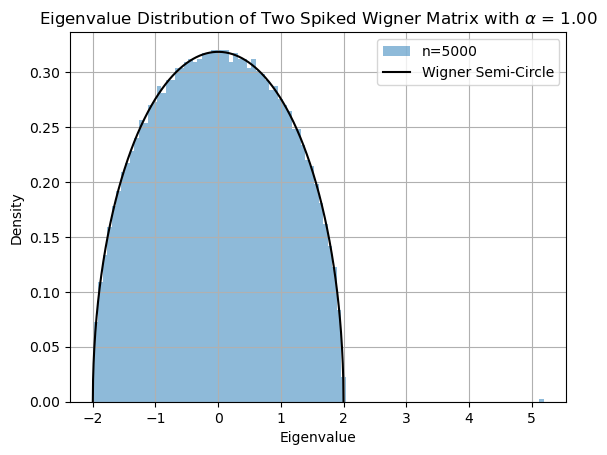

In [31]:
importlib.reload(m)
alphas = np.linspace(0, 1, 5)
lamba_1 = 5
lamba_2 = 4
rho = 0.2
N = 5000

for alpha in alphas:
    M = m.TwoSpikedWignerMatrix(N, lamba_1, lamba_2, rho, alpha)
    M.plot_eigenvalue_distribution()
    
    M.ploplote(title = rf'Eigenvalue Distribution of Two Spiked Wigner Matrix with $\alpha$ = {alpha:.2f}', savefig = f'Two_Spiked_Wigner_alpha_{alpha:.2f}', Wigner=True, grid=True)

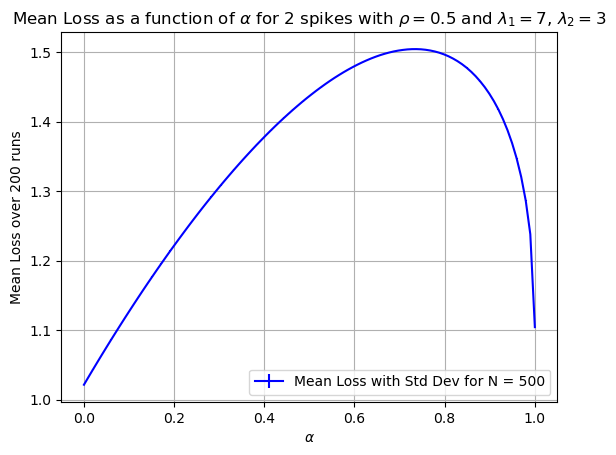

In [ ]:
importlib.reload(m)

alphas = np.linspace(0, 1, 100)
losses = []
losses_std = []
N = 500
rhos = np.linspace(0, 1, 4)
lamba_1 = 7
lamba_2 = 3
M = m.TwoSpikedWignerMatrix(N, lamba_1, lamba_2, rho, 0.5)
for rho in rhos:
    for alpha in alphas:    
        M = m.TwoSpikedWignerMatrix(N, lamba_1, lamba_2, rho, alpha)
        loss = []
        for i in range(200):
                x_hat = np.random.normal(0, 1, N)
                x_hat = x_hat / np.linalg.norm(x_hat)
                loss.append(M.loss(x_hat))
        losses.append(np.mean(loss))
        losses_std.append(np.std(loss))
    #print(f"Alpha: {alpha}, Mean Loss: {loss}")
    plt.errorbar(alphas, losses, yerr=losses_std, color='blue', label=f'Mean Loss with Std Dev for {rho:.2f}')
m.ploplote_moi_ca(xlabel=r'$\alpha$', ylabel='Mean Loss over 200 runs', title=r'Mean Loss for 2 spikes with $\lambda_1 = 7$, $\lambda_2 = 3$, $n = 500$', savefig='Mean_Loss_vs_Alpha', grid=True, legend=True)

#we observe the curve has a maximum at around 0.7, which looks weird.

#We check by plotting the overlap:




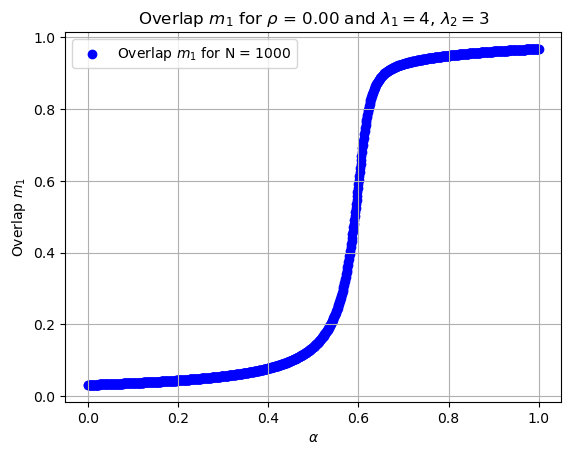

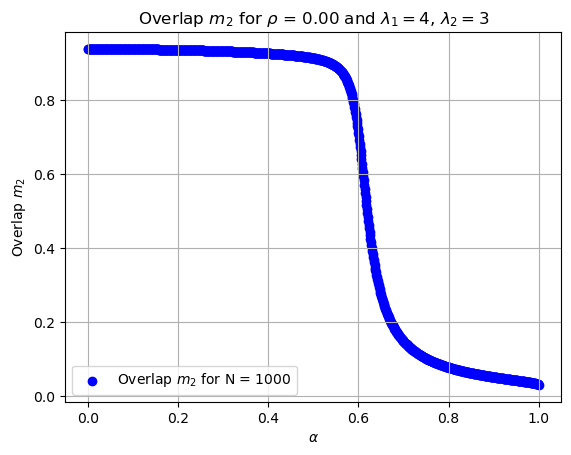

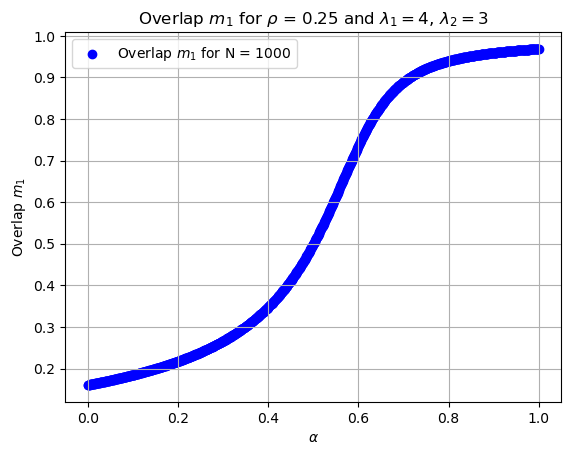

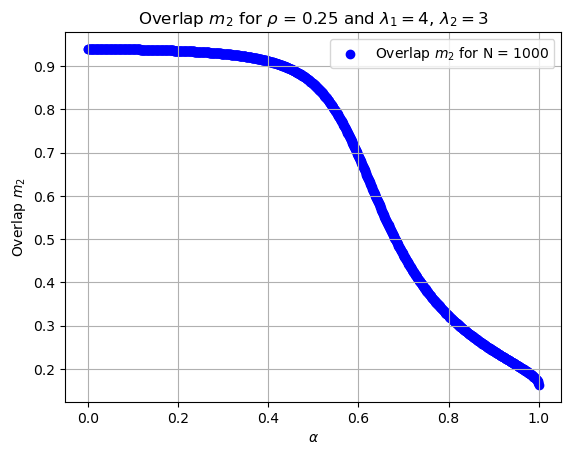

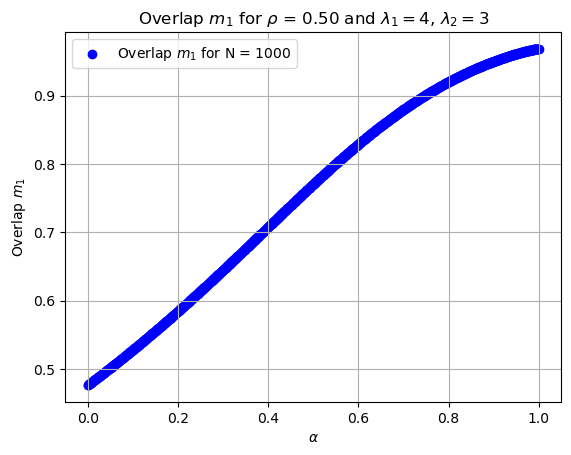

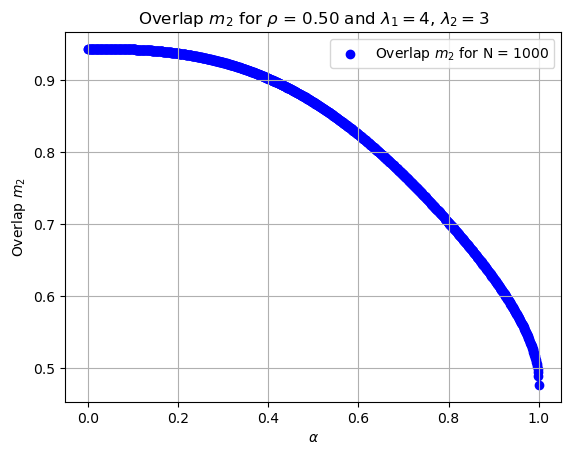

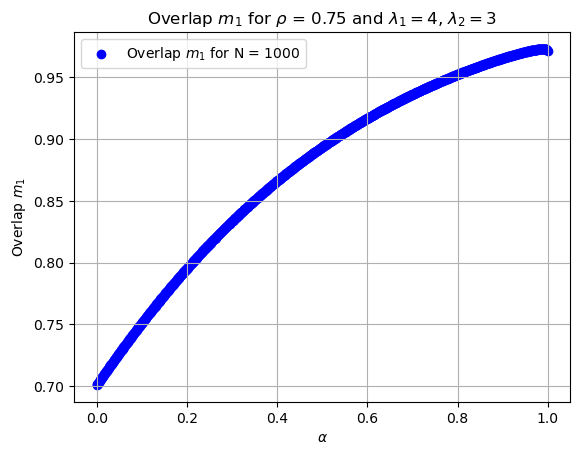

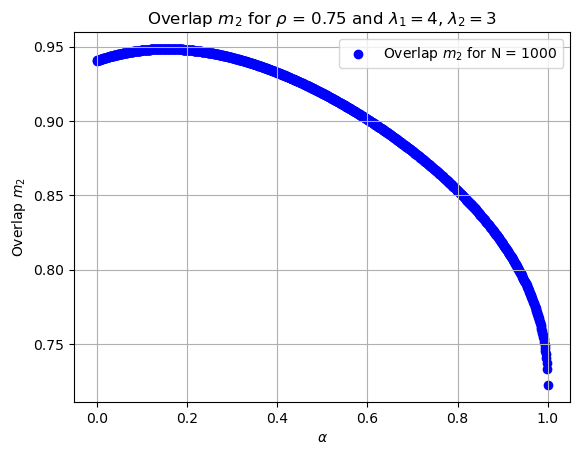

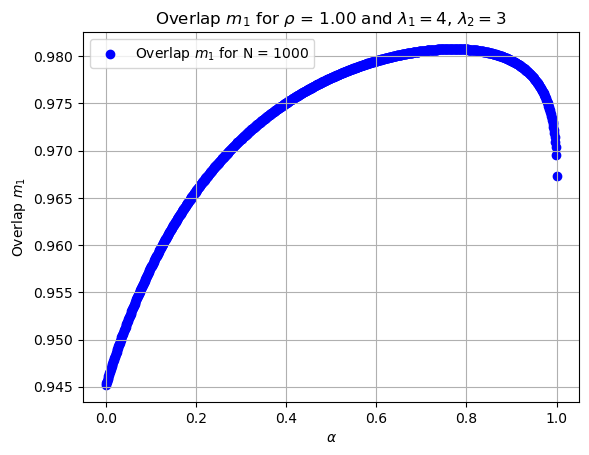

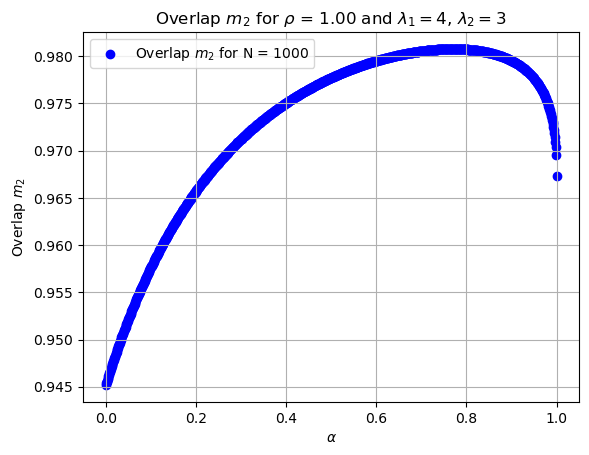

In [50]:
importlib.reload(m)

alphas = np.linspace(0, 1, 1000)
N = 1000
rhos = np.linspace(0, 1, 5)
lamba_1 = 4
lamba_2 = 3
# I will plot the loss as a function of alpha, each time I will degerate random values of x_hat, and average the loss over them
N_gradient_descent = 10000

for rho in rhos:
    M = m.TwoSpikedWignerMatrix(N, lamba_1, lamba_2, rho, 0)
    overlap_1 = []
    overlap_2 = []
    for alpha in alphas:
        M.new_alpha(alpha)
        x_hat = np.random.normal(0, 1, N)
        x_hat = x_hat / np.linalg.norm(x_hat)
        x_hat = M.power_iteration(x_hat, N_gradient_descent)
        overlap_1.append(M.overlap1(x_hat))
        overlap_2.append(M.overlap2(x_hat))
    plt.scatter(alphas, overlap_1, color='blue', label='Overlap $m_1$ for N = 1000')
    m.ploplote_moi_ca(xlabel=r'$\alpha$', ylabel=r'Overlap $m_1$', title=rf'Overlap $m_1$ for $\rho$ = {rho:.2f} and $\lambda_1 = 4$, $\lambda_2 = 3$', savefig=f'Overlap_m1_vs_Alpha_rho={rho:.2f}', grid=True, legend=True)
    plt.scatter(alphas, overlap_2, color='blue', label='Overlap $m_2$ for N = 1000')
    m.ploplote_moi_ca(xlabel=r'$\alpha$', ylabel=r'Overlap $m_2$', title=rf'Overlap $m_2$ for $\rho$ = {rho:.2f} and $\lambda_1 = 4$, $\lambda_2 = 3$', savefig=f'Overlap_m2_vs_Alpha_rho={rho:.2f}', grid=True, legend=True)

<ErrorbarContainer object of 3 artists>

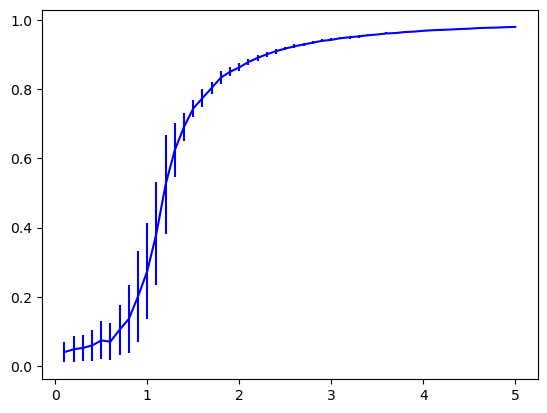

In [ ]:
#just plot overlap as a function of lamba here, for one spike:
importlib.reload(m)
N = 500
N_average = 50
M = m.SpikedWignerMatrix(N, 0) # we start with no spike, we will change lambda later
lambas = np.linspace(0.1, 5, 50)
overlap = []
theoretical_overlap = []
std_overlap = []
for lamba in lambas:
    x_avg = []
    for i in range(N_average):
        M = m.SpikedWignerMatrix(N, lamba)  # fresh Wigner + fresh spike each time
        x_hat = M.max_eigenvector()
        x_avg.append(M.overlap1(x_hat))
    #theoretical_overlap.append(M.theoretical_max_eigenvalue()-2)
    overlap.append(np.mean(x_avg))
    std_overlap.append(np.std(x_avg))
#plt.plot(lambas, overlap, color='blue')
plt.errorbar(lambas, overlap, yerr=std_overlap, color='blue')
#plt.plot(lambas, theoretical_overlap, color='red', linestyle='--')

In [ ]:
#Now lets try to plot when we recover x as a function of lamba. To do this, we plot the overlap as before as a function of lambda, then we add red color if the overlap is greater than a certain value that is 1e-2. For one spike first.

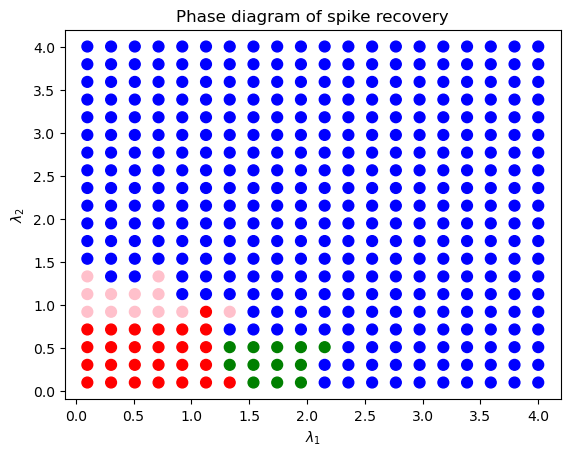

In [ ]:
importlib.reload(m)
N = 500
lambas1 = np.linspace(0.1, 4, 20)
lambas2 = np.linspace(0.1, 4, 20)
rho = 0.2
alpha = 0.5
N_gradient_descent = 100
ep = 1e-1
N_average = 10

colors = []
x_vals = []
y_vals = []

M = m.TwoSpikedWignerMatrix(N, 0, 0, rho, alpha)


for lamba1 in lambas1:
    for lamba2 in lambas2:
        m_avg_1 = []
        m_avg_2 = []
        for i in range(N_average):
            M = m.TwoSpikedWignerMatrix(N, lamba1, lamba2, rho, alpha) 
            x_hat = np.random.normal(0, 1, N)
            x_hat = x_hat / np.linalg.norm(x_hat)
            x_hat = M.adam(x_hat, 0.01, N_gradient_descent)
            m_avg_1.append(M.overlap1(x_hat))
            m_avg_2.append(M.overlap2(x_hat))
        overlap_1 = np.mean(m_avg_1)
        overlap_2 = np.mean(m_avg_2)

        x_vals.append(lamba1)
        y_vals.append(lamba2)

        if overlap_1 > ep and overlap_2 > ep:
            colors.append("blue")

        elif overlap_1 < ep and overlap_2 < ep:
            colors.append("red")

        elif overlap_1 > ep:
            colors.append("green")

        else:
            colors.append("pink")
     #std_overlap.append(np.std(x_avg))
plt.scatter(x_vals, y_vals, c=colors, s=60, )

plt.xlabel(r"$\lambda_1$")
plt.ylabel(r"$\lambda_2$")
plt.title("Phase diagram of spike recovery")
plt.savefig('../Plots/Phase_Diagram.png')
plt.show()

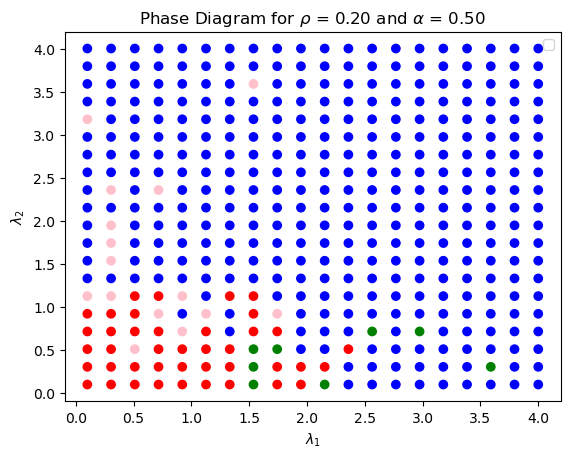

In [55]:
importlib.reload(m)
N = 500
lambas1 = np.linspace(0.1, 4, 20)
lambas2 = np.linspace(0.1, 4, 20)
rho = 0.2
alpha = 0.5
N_gradient_descent = 10000
ep = 1e-1
N_average = 1      #no need for more with poweriteration

x_vals, y_vals, colors = m.phase_diagram(N, rho, alpha, lambas1, lambas2, N_gradient_descent, ep, N_average)
plt.scatter(x_vals, y_vals, c=colors)
m.ploplote_moi_ca(xlabel=r'$\lambda_1$', ylabel=r'$\lambda_2$', title=rf'Phase Diagram for $\rho$ = {rho:.2f} and $\alpha$ = {alpha:.2f}', savefig=f'Phase_Diagram_rho={rho:.2f}_and_alpha={alpha:.2f}', grid=False, legend=True)

/Users/talizou/Documents/Physics_The_Projects/Spike_code/model_2.py:241: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if legend:plt.legend()


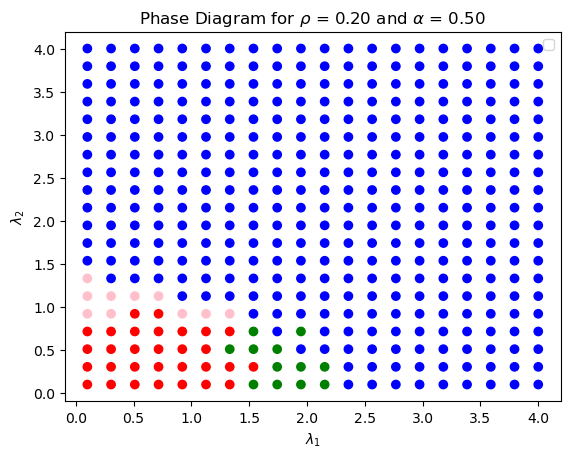

In [56]:
importlib.reload(m)
N = 500
lambas1 = np.linspace(0.1, 4, 20)
lambas2 = np.linspace(0.1, 4, 20)
rho = 0.2
alpha = 0.5
N_gradient_descent = 10000
threshold = 0.1
N_average = 10      #no need for more with poweriteration

x_vals, y_vals, colors = m.phase_diagram(N, rho, alpha, lambas1, lambas2, N_gradient_descent, threshold, N_average)
plt.scatter(x_vals, y_vals, c=colors)
m.ploplote_moi_ca(xlabel=r'$\lambda_1$', ylabel=r'$\lambda_2$', title=rf'Phase Diagram for $\rho$ = {rho:.2f} and $\alpha$ = {alpha:.2f}', savefig=f'Phase_Diagram_rho={rho:.2f}_and_alpha={alpha:.2f}', grid=False, legend=True)

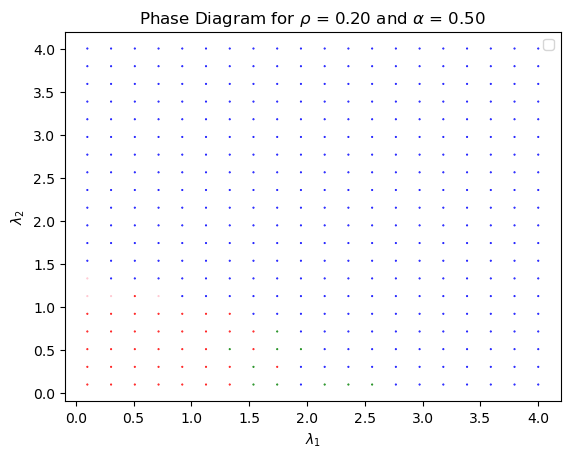

In [61]:
importlib.reload(m)
N = 500
lambas1 = np.linspace(0.1, 4, 20)
lambas2 = np.linspace(0.1, 4, 20)
rho = 0.2
alpha = 0.5
N_gradient_descent = 10000
threshold = 0.1
N_average = 5      #no need for more with poweriteration

x_vals, y_vals, colors = m.phase_diagram(N, rho, alpha, lambas1, lambas2, N_gradient_descent, threshold, N_average)
plt.scatter(x_vals, y_vals, c=colors, s=1, marker='.')
m.ploplote_moi_ca(xlabel=r'$\lambda_1$', ylabel=r'$\lambda_2$', title=rf'Phase Diagram for $\rho$ = {rho:.2f} and $\alpha$ = {alpha:.2f}', savefig=f'Phase_Diagram_rho={rho:.2f}_and_alpha={alpha:.2f}', grid=False, legend=True)

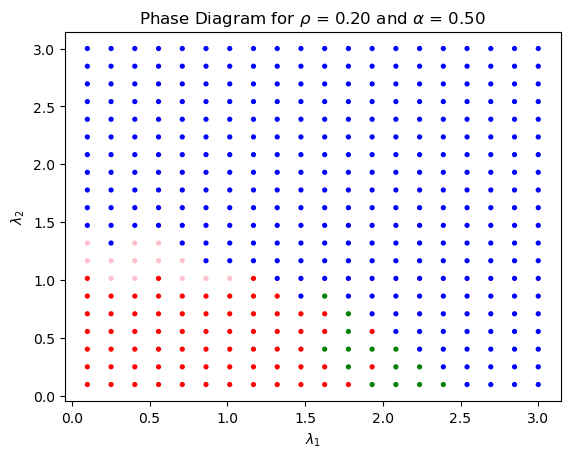

In [73]:
importlib.reload(m)
N = 500
lambas1 = np.linspace(0.1, 3, 20)
lambas2 = np.linspace(0.1, 3, 20)
rho = 0.2
alpha = 0.5
N_gradient_descent = 10000
threshold = 0.1
N_average = 30

x_vals, y_vals, colors = m.phase_diagram_parallel(N, rho, alpha, lambas1, lambas2, N_gradient_descent, threshold, N_average)
plt.scatter(x_vals, y_vals, c=colors, s=30, marker='.')
m.ploplote_moi_ca(xlabel=r'$\lambda_1$', ylabel=r'$\lambda_2$', title=rf'Phase Diagram for $\rho$ = {rho:.2f} and $\alpha$ = {alpha:.2f}', savefig=f'Phase_Diagram_rho={rho:.2f}_and_alpha={alpha:.2f}', grid=False, legend=False)

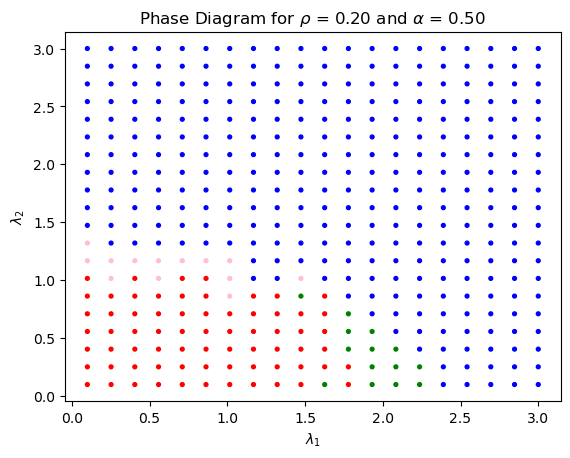

In [ ]:
importlib.reload(m)
N = 500
lambas1 = np.linspace(0.1, 5, 50)
lambas2 = np.linspace(0.1, 5, 50)
rho = 0.2
alphas = np.linspace(0, 1, 6)

N_gradient_descent = 10000
threshold = 0.1
N_average = 30

for alpha in alphas:
    x_vals, y_vals, colors = m.phase_diagram_parallel(N, rho, alpha, lambas1, lambas2, N_gradient_descent, threshold, N_average)
    plt.scatter(x_vals, y_vals, c=colors, s=1, marker='.')
    m.ploplote_moi_ca(xlabel=r'$\lambda_1$', ylabel=r'$\lambda_2$', title=rf'Phase Diagram for $\rho$ = {rho:.2f} and $\alpha$ = {alpha:.2f}', savefig=f'Phase_Diagram_rho={rho:.2f}_and_alpha={alpha:.2f}', grid=False, legend=False)